# Abertura e Fechamento Morfológica 

Este notebook mostra, de forma **didática e comparativa**, como funcionam as operações morfológicas
**Abertura** e **Fechamento** em imagens binárias (0/255), usando:


### Importações

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from pathlib import Path
import math

sys.path.append(str(Path().resolve().parent))

import utils as ut
plt.rcParams["figure.figsize"] = (10, 4)

### Leitura da imagem

In [2]:
IMG_PATH = Path("finger-print.PNG")

image = cv.imread(str(IMG_PATH), cv.IMREAD_COLOR)

if image is None:
    raise FileNotFoundError(f"Não consegui ler o arquivo: {IMG_PATH.resolve()}")

print("Imagem carregada com sucesso!", image.shape, image.dtype)

Imagem carregada com sucesso! (602, 796, 3) uint8


### Análise exploratória

In [3]:
ut.eda_image(image)

Largura em pixels: 602
Altura em pixels: 796
Quantidade de pixels: 479192
Quantidade de elementos presentes na matriz: 1437576
Quantidade de canais: 3


### Conversão para tons de cinza

Aqui usamos a função do seu `utils.py` (`generate_gray_channel`), que faz a média simples dos canais:
\[
gray = \frac{B + G + R}{3}
\]

> O OpenCV tem `cv.cvtColor(..., cv.COLOR_BGR2GRAY)`, mas vamos seguir a implementação manual do trabalho.


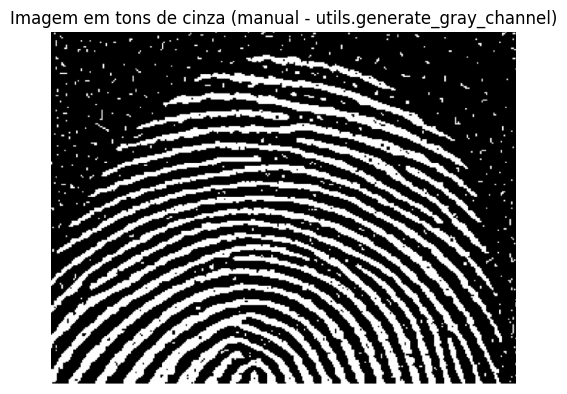

Gray: (602, 796) uint8 min/max: 0 255


In [4]:
gray = ut.generate_gray_channel(image)

plt.figure(figsize=(6, 5))
plt.imshow(gray, cmap="gray")
plt.title("Imagem em tons de cinza (manual - utils.generate_gray_channel)")
plt.axis("off")
plt.show()

print("Gray:", gray.shape, gray.dtype, "min/max:", int(gray.min()), int(gray.max()))

### Histograma (tons de cinza)

O histograma ajuda a escolher um limiar (threshold) para binarização.
Vamos usar `ut.histograma` e depois plotar.

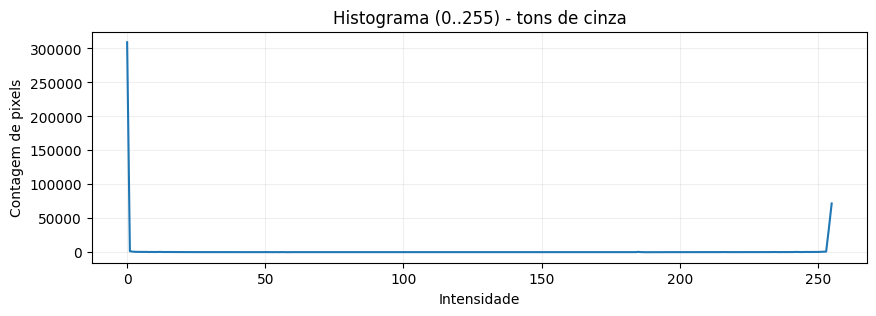

In [5]:
hist = ut.histograma(gray)

plt.figure(figsize=(10, 3))
plt.plot(hist)
plt.title("Histograma (0..255) - tons de cinza")
plt.xlabel("Intensidade")
plt.ylabel("Contagem de pixels")
plt.grid(True, alpha=0.2)
plt.show()

### Binarização + escolha de **objeto** e **fundo**

Operações morfológicas binárias normalmente assumem:

- **Objeto (foreground)**: 255 (branco)
- **Fundo (background)**: 0 (preto)

Se você trabalhar com o contrário (objeto preto em fundo branco), é comum acontecer o efeito de
“**dilatação parecer erosão**”, porque você está, na prática, expandindo o fundo (branco) e “comendo” o objeto (preto).

Abaixo vamos:
1. Binarizar com Otsu (automático)
2. Garantir que o **objeto fique branco (255)** para usar as funções do `utils.py`

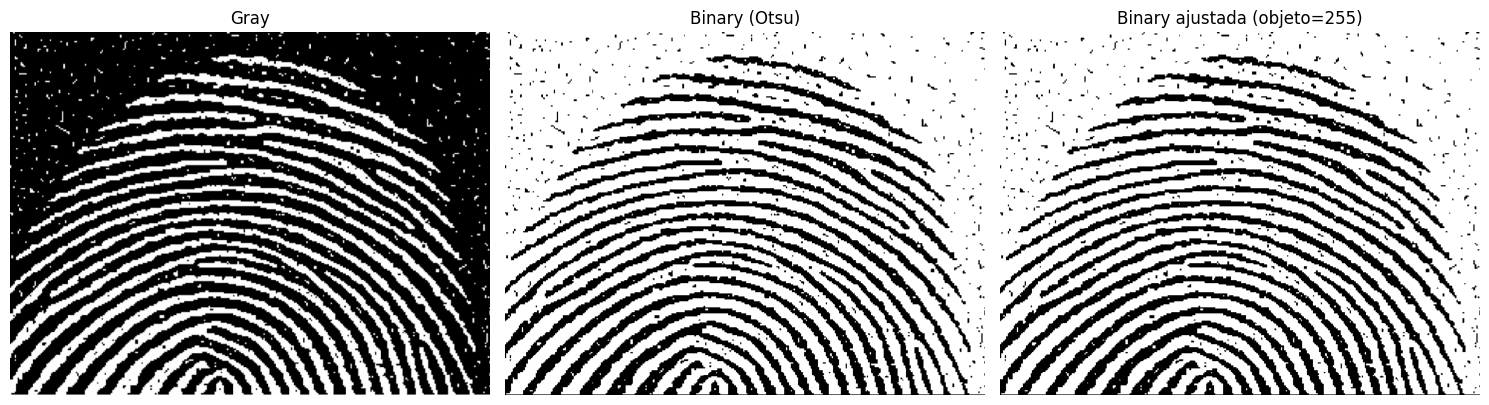

mean(binary_raw) = 181.42765321624734 | mean(binary) = 181.42765321624734


In [6]:
# Otsu escolhe automaticamente o limiar (bom ponto de partida)
_, binary_raw = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

# Heurística simples: se a imagem binária ficou "muito branca", provavelmente o fundo é branco
# e o objeto é preto -> invertendo, garantimos objeto branco em fundo preto.
if np.mean(binary_raw) > 127:
    binary = 255 - binary_raw
else:
    binary = binary_raw.copy()
    
binary = cv.bitwise_not(binary) 

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(gray, cmap="gray"); ax[0].set_title("Gray"); ax[0].axis("off")
ax[1].imshow(binary_raw, cmap="gray"); ax[1].set_title("Binary (Otsu)"); ax[1].axis("off")
ax[2].imshow(binary, cmap="gray"); ax[2].set_title("Binary ajustada (objeto=255)"); ax[2].axis("off")
plt.tight_layout()
plt.show()

print("mean(binary_raw) =", float(np.mean(binary_raw)), "| mean(binary) =", float(np.mean(binary)))

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1) Ler em tons de cinza
gray = cv.imread("finger-print.PNG", cv.IMREAD_GRAYSCALE)

# (opcional) suaviza um pouco antes do Otsu (ajuda com ruído)
blur = cv.GaussianBlur(gray, (5, 5), 0)

# 2) Binarização (Otsu)
# OBS: aqui use THRESH_BINARY ou THRESH_BINARY_INV dependendo do seu caso.
_, binary = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Se no seu resultado o FUNDO ficou branco e o DEDO ficou preto, inverta:
# (assim o "objeto" vira branco=255, que é o padrão da morfologia)
if (binary == 255).mean() > 0.5:  # fundo mais branco que preto -> dedo provavelmente preto
    binary_fg = 255 - binary
else:
    binary_fg = binary

# 3) Abertura e Fechamento
# Kernel pequeno (3x3) costuma remover os pontinhos sem destruir as cristas
se_open  = ut.make_se(3, shape="ellipse")
se_close = ut.make_se(3, shape="ellipse")

opened = ut.manual_opening(binary_fg, se_open, iterations=3)
clean_fg = ut.manual_closing(opened, se_close, iterations=1)

# Se você quiser voltar pro estilo "fundo branco, dedo preto":
clean = 255 - clean_fg if (binary == 255).mean() > 0.5 else clean_fg

# 4) Visualização
plt.figure(figsize=(14, 4))
imgs = [(gray, "Gray"), (binary, "Binary (Otsu)"), (clean, "Após Abertura+Fechamento")]
for i, (im, title) in enumerate(imgs, 1):
    plt.subplot(1, 3, i)
    plt.imshow(im, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

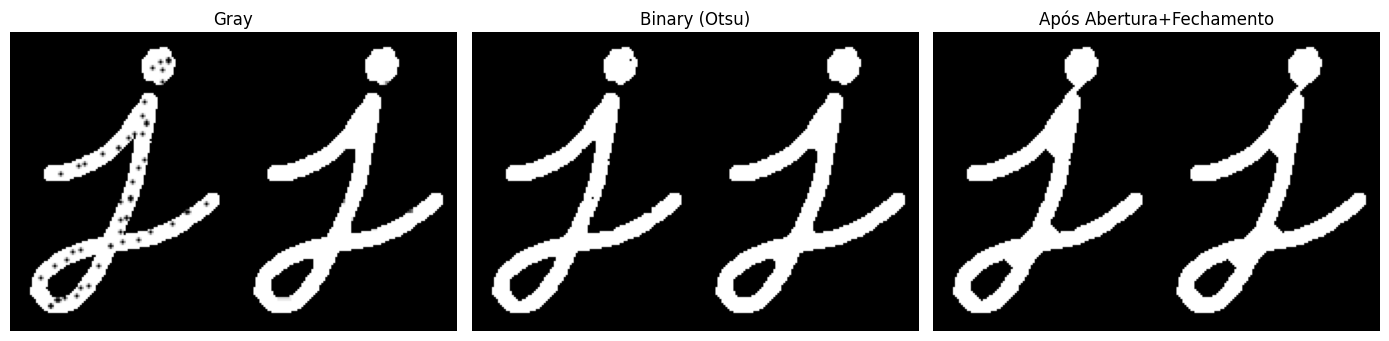

In [ ]:
# 1) Ler em tons de cinza
gray = cv.imread("closing.png", cv.IMREAD_GRAYSCALE)

# (opcional) suaviza um pouco antes do Otsu (ajuda com ruído)
blur = cv.GaussianBlur(gray, (5, 5), 0)

# 2) Binarização (Otsu)
# OBS: aqui use THRESH_BINARY ou THRESH_BINARY_INV dependendo do seu caso.
_, binary = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Se no seu resultado o FUNDO ficou branco e o DEDO ficou preto, inverta:
# (assim o "objeto" vira branco=255, que é o padrão da morfologia)
if (binary == 255).mean() > 0.5:  # fundo mais branco que preto -> dedo provavelmente preto
    binary_fg = 255 - binary
else:
    binary_fg = binary

# 3) Abertura e Fechamento
# Kernel pequeno (3x3) costuma remover os pontinhos sem destruir as cristas
se_open  = ut.make_se(3, shape="ellipse")
se_close = ut.make_se(3, shape="ellipse")

clean_fg = ut.manual_closing(binary_fg, se_close, iterations=4)
opened = ut.manual_opening(clean_fg, se_open, iterations=1)

# Se você quiser voltar pro estilo "fundo branco, dedo preto":
clean = 255 - clean_fg if (binary == 255).mean() > 0.5 else clean_fg

# 4) Visualização
plt.figure(figsize=(14, 4))
imgs = [(gray, "Gray"), (binary, "Binary (Otsu)"), (clean, "Após Abertura+Fechamento")]
for i, (im, title) in enumerate(imgs, 1):
    plt.subplot(1, 3, i)
    plt.imshow(im, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()